In [1]:
from astropy import table

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    plot_raw_phase_folded_lightcurve,
    attach_flux_mean_magnitudes,
    attach_periodogram_periods,
    plot_lomb_scargle_periodogram,
    plot_period_mean_g,
    plot_vari_rrlyrae_period_comparison,
)



Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
query = """
SELECT TOP 100 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND num_clean_epochs_g > 40
ORDER BY num_clean_epochs_g DESC
"""


In [3]:
rrlyrae = GaiaData(query, include_lightcurve=True)

rrlyrae.data[:10]


solution_id,source_id,pf,pf_error,p1_o,p1_o_error,epoch_g,epoch_g_error,epoch_bp,epoch_bp_error,epoch_rp,epoch_rp_error,epoch_rv,epoch_rv_error,int_average_g,int_average_g_error,int_average_bp,int_average_bp_error,int_average_rp,int_average_rp_error,average_rv,average_rv_error,peak_to_peak_g,peak_to_peak_g_error,peak_to_peak_bp,peak_to_peak_bp_error,peak_to_peak_rp,peak_to_peak_rp_error,peak_to_peak_rv,peak_to_peak_rv_error,metallicity,metallicity_error,r21_g,r21_g_error,r31_g,r31_g_error,phi21_g,phi21_g_error,phi31_g,phi31_g_error,num_clean_epochs_g,num_clean_epochs_bp,num_clean_epochs_rp,num_clean_epochs_rv,zp_mag_g,zp_mag_bp,zp_mag_rp,num_harmonics_for_p1_g,num_harmonics_for_p1_bp,num_harmonics_for_p1_rp,num_harmonics_for_p1_rv,reference_time_g,reference_time_bp,reference_time_rp,reference_time_rv,fund_freq1,fund_freq1_error,fund_freq2,fund_freq2_error,fund_freq1_harmonic_ampl_g,fund_freq1_harmonic_ampl_g_error,fund_freq1_harmonic_phase_g,fund_freq1_harmonic_phase_g_error,fund_freq1_harmonic_ampl_bp,fund_freq1_harmonic_ampl_bp_error,fund_freq1_harmonic_phase_bp,fund_freq1_harmonic_phase_bp_error,fund_freq1_harmonic_ampl_rp,fund_freq1_harmonic_ampl_rp_error,fund_freq1_harmonic_phase_rp,fund_freq1_harmonic_phase_rp_error,fund_freq1_harmonic_ampl_rv,fund_freq1_harmonic_ampl_rv_error,fund_freq1_harmonic_phase_rv,fund_freq1_harmonic_phase_rv_error,best_classification,g_absorption,g_absorption_error
,,d,d,d,d,d,d,d,d,d,d,d,d,mag,mag,mag,mag,mag,mag,km / s,km / s,mag,mag,mag,mag,mag,mag,km / s,km / s,dex,dex,,,,,rad,rad,rad,rad,,,,,mag,mag,mag,,,,,d,d,d,d,1 / d,1 / d,1 / d,1 / d,mag,mag,rad,rad,mag,mag,rad,rad,mag,mag,rad,rad,km / s,km / s,rad,rad,,mag,mag
int64,int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,int16,int16,int16,int16,float64,float64,float64,float64,float64,float32,float64,float32,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float32,float32
375316653866487565,5284173207165634048,0.6754204135600004,1.14527e-05,--,--,1664.7147255940913,1.6196564e-05,1664.725090176758,4.3462893e-05,1664.7448980260845,5.088851e-05,--,--,19.021461,0.0015568832,19.218428,0.0108482,18.57285,0.007794851,--,--,0.23490465,0.005222299,0.25476402,0.03279039,0.19802193,0.020892723,--,--,-0.9399567,0.39976972,0.3227774,0.021646043,0.1224213,0.021695046,4.2703824,0.08953599,2.5574005,0.23331897,257,246,242,--,19.02329,19.22096,18.573446,3,2,2,--,1666.4768974530693,1666.4772118301444,1666.4773006462092,--,1.4805593374491128,2.5104959e-05,--,--,[0.10287211835384369 0.03320479393005371 0.012593737803399563 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.002026671776548028 0.002223402028903365 0.002232055412605405 -- -- --\n -- -- -- -- -- -- -- -- -- --],[0.21112152934074402 4.692625045776367 3.190765142440796 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0],[0.027860915288329124 0.06460897624492645 0.2089683562517166 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.11212261021137238 0.046277161687612534 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.018480001017451286 0.02448887564241886 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.45994314551353455 4.471524715423584 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.16694127023220062 0.6190136075019836 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.06839297711849213 0.04667317494750023 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.011212748475372791 0.009829183109104633 -- -- -- -- -- -- -- -- -- --\n -- -- -- --],[6.272590160369873 4.2616424560546875 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.17579962313175201 0.2635345757007599 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[],[],[],[],

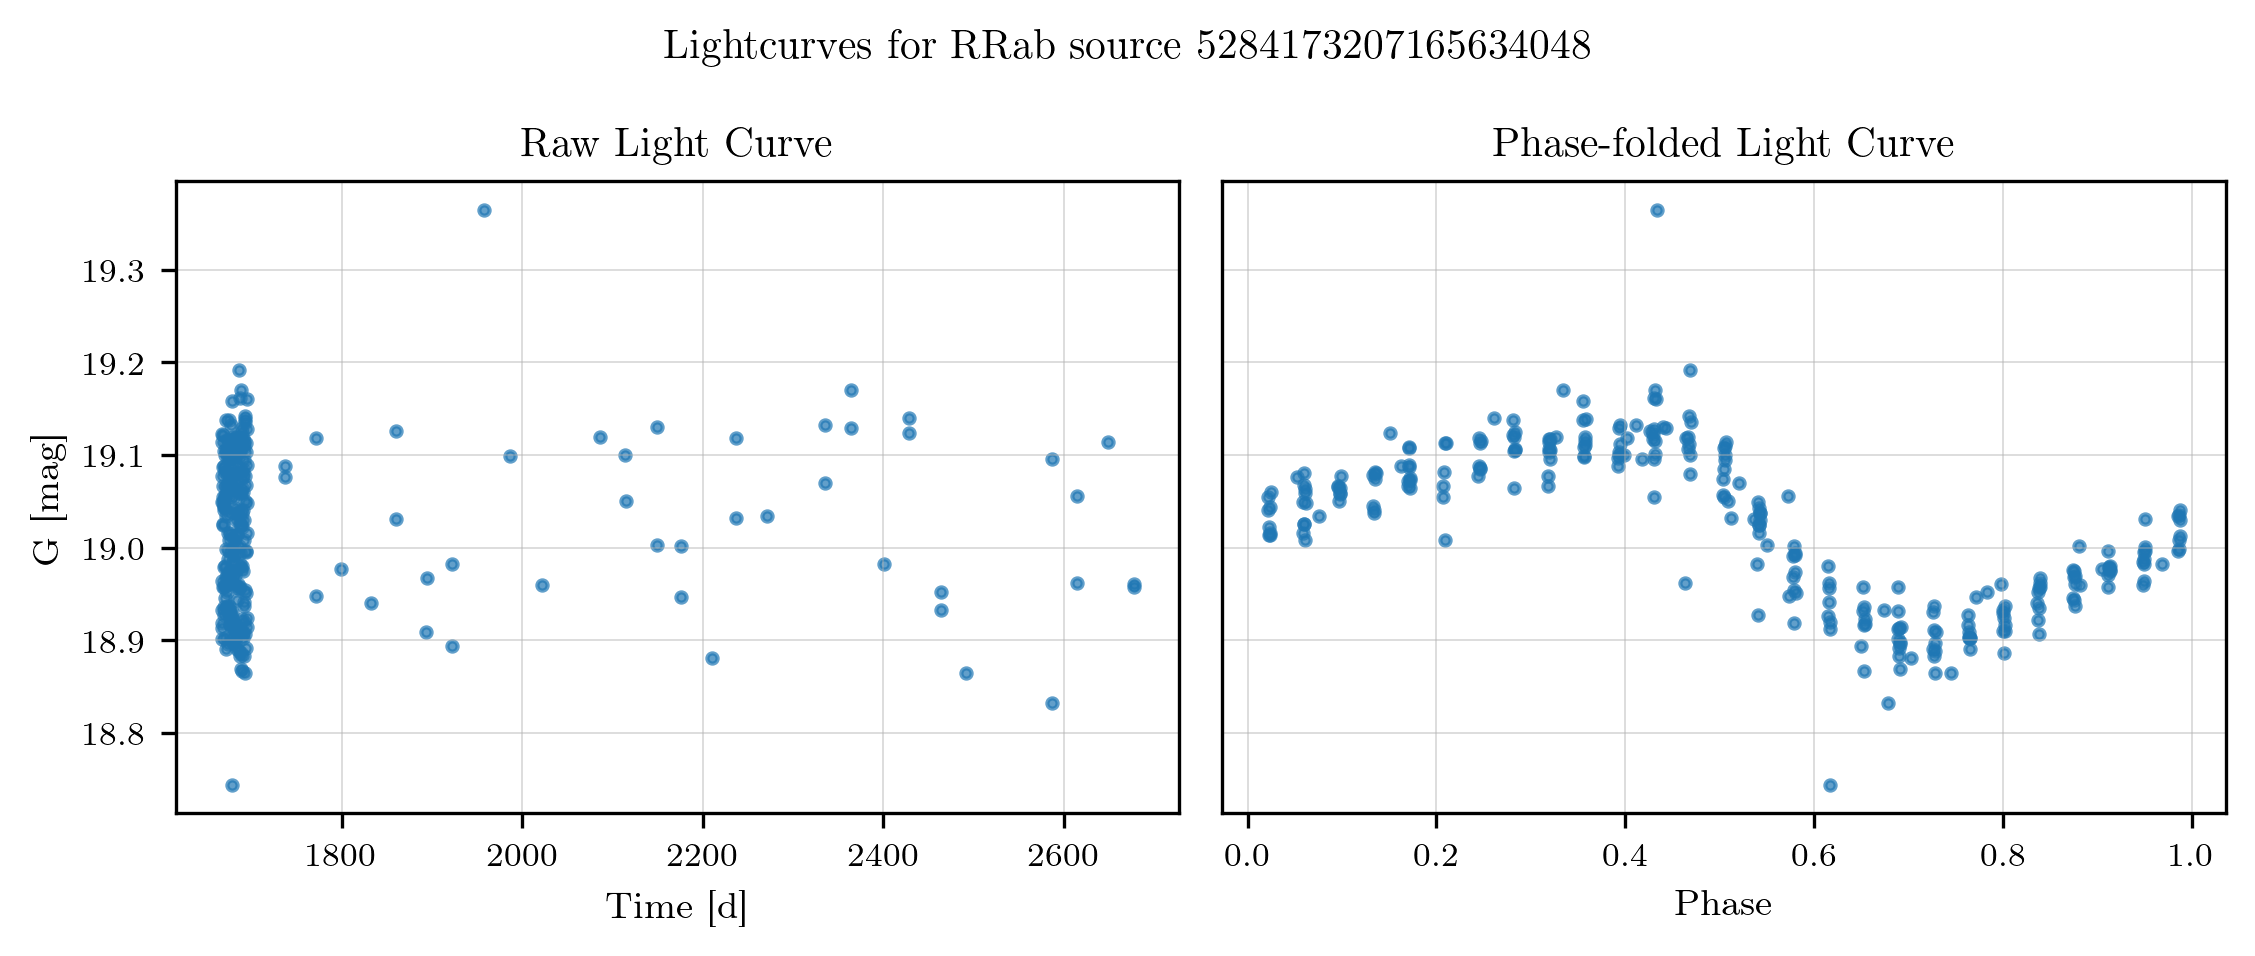

In [4]:
first_star = rrlyrae.data[0]
source_id = int(first_star["source_id"])
best_classification = str(first_star["best_classification"])
adopted_period = float(first_star["pf"])

axes = plot_raw_phase_folded_lightcurve(
    rrlyrae,
    source_id=source_id,
    period=adopted_period,
    title=f"Lightcurves for {best_classification} source {source_id}",
)
plt.tight_layout()
plt.show()


In [5]:
lightcurve_data = attach_periodogram_periods(attach_flux_mean_magnitudes(rrlyrae.lightcurve_data))

source_id_values = np.asarray(lightcurve_data["source_id"], dtype=np.int64)
source_ids, first_idx, counts = np.unique(source_id_values, return_index=True, return_counts=True)
summary_rows = lightcurve_data[np.asarray(first_idx, dtype=int)]

summary = table.Table(
    {
        "source_id": np.asarray(source_ids, dtype=np.int64),
        "best_classification": summary_rows["best_classification"],
        "n_epochs": np.asarray(counts, dtype=int),
        "pf": np.asarray(np.ma.filled(summary_rows["pf"], np.nan), dtype=float),
        "p1_o": np.asarray(np.ma.filled(summary_rows["p1_o"], np.nan), dtype=float),
        "best_period": np.asarray(summary_rows["period_ls"], dtype=float),
        "mean_apparent_g": np.asarray(summary_rows["mean_g_transit_mag"], dtype=float),
        "mean_apparent_g_err": np.asarray(summary_rows["mean_g_transit_mag_err"], dtype=float),
    }
)

summary[
    "source_id",
    "best_classification",
    "n_epochs",
    "pf",
    "p1_o",
    "best_period",
    "mean_apparent_g",
    "mean_apparent_g_err",
][:10]

source_id,best_classification,n_epochs,pf,p1_o,best_period,mean_apparent_g,mean_apparent_g_err
int64,object,int64,float64,float64,float64,float64,float64
2161723289949628288,RRab,254,0.52120744664845,nan,0.5211808286461959,18.012706411438742,0.003122876604886266
4659671699480524672,RRab,250,0.5727057170646728,nan,0.572702616543498,19.03500324830371,0.0041710843987278505
4659671768199981824,RRd,247,0.5105986492527866,0.3808748574875205,0.38087821986401127,18.98922312099697,0.014172054749079064
4659672936432993408,RRab,258,0.5565264350513908,nan,0.5565438793427747,19.20513384670247,0.004409149871041425
4659675509114516224,RRd,248,0.4718617187502126,0.3508347485188077,0.3508415070658297,19.28913005581656,0.003783440294753638
4659692830708745472,RRd,259,0.49809852140300886,0.3707070836042074,0.37071438279554514,18.974257588073677,0.003940670502140079
4659694067664043648,RRab,254,0.5121978022026014,nan,0.5121839872734384,18.785753745251437,0.003289787097450397
4659694239447681792,RRab,253,0.5828427671637346,nan,0.5828626801775547,19.36131846177173,0.004119463702611087
4659703069916687872,RRab,246,0.5584606987263409,nan,0.5584620963988325,19.038591451716268,0.004577405316774536


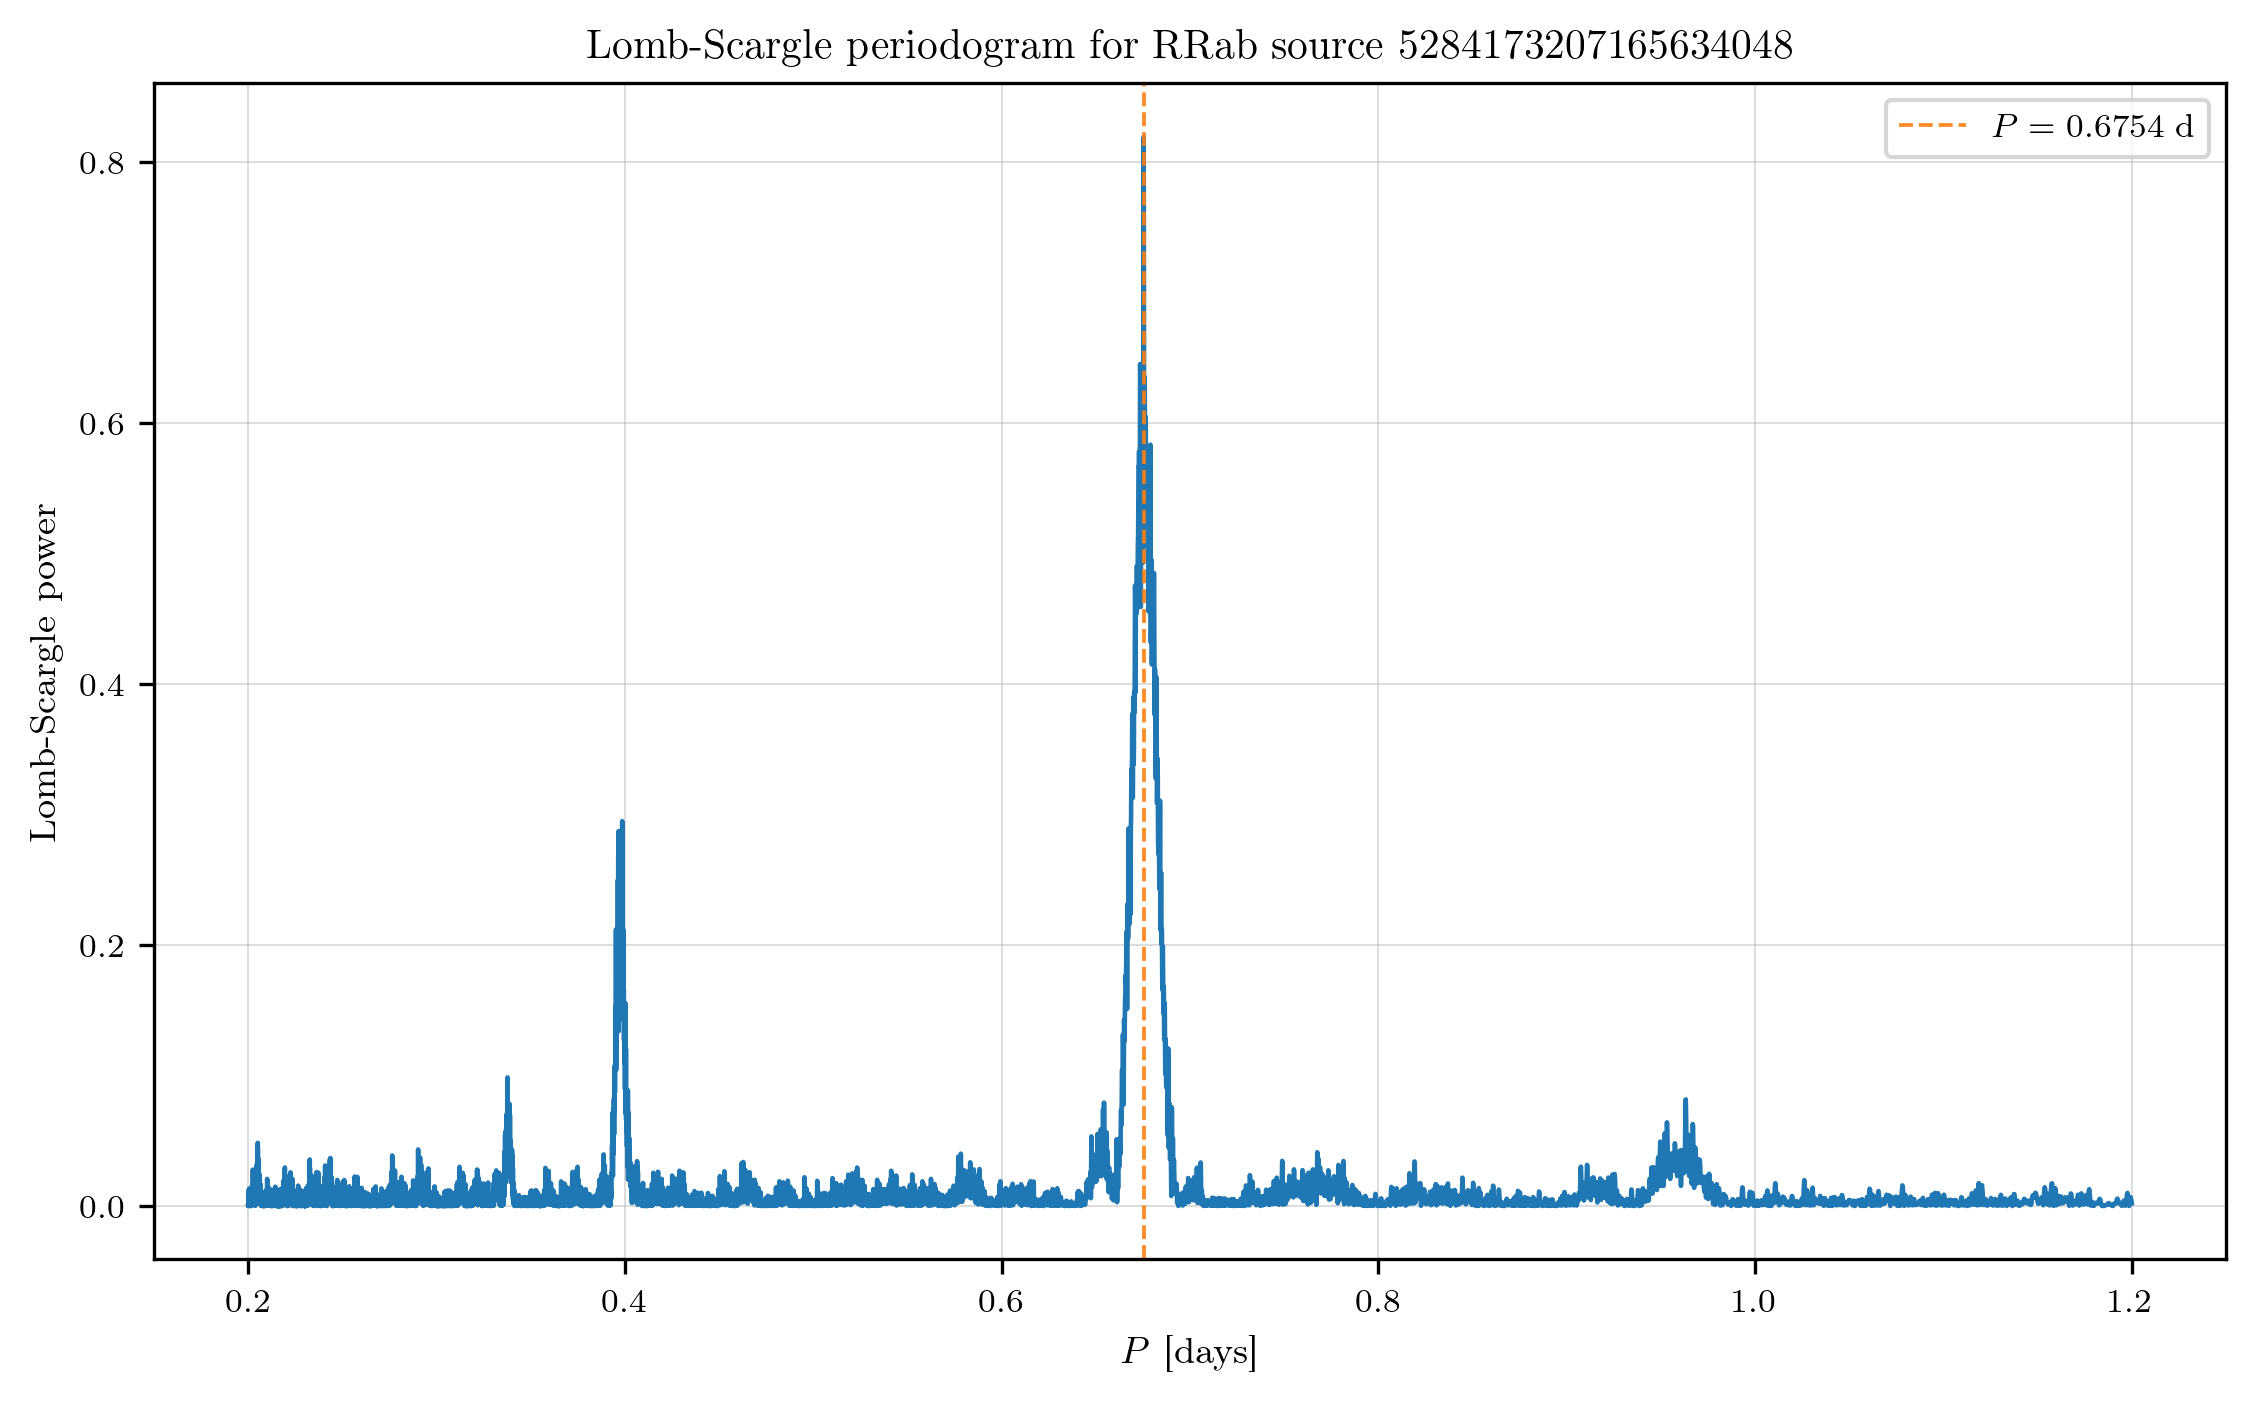

In [6]:
target = lightcurve_data[np.asarray(lightcurve_data["source_id"], dtype=np.int64) == source_id]
best_classification = str(target[0]["best_classification"])

ax = plot_lomb_scargle_periodogram(
    target,
    title=f"Lomb-Scargle periodogram for {best_classification} source {source_id}",
)
plt.tight_layout()
plt.show()

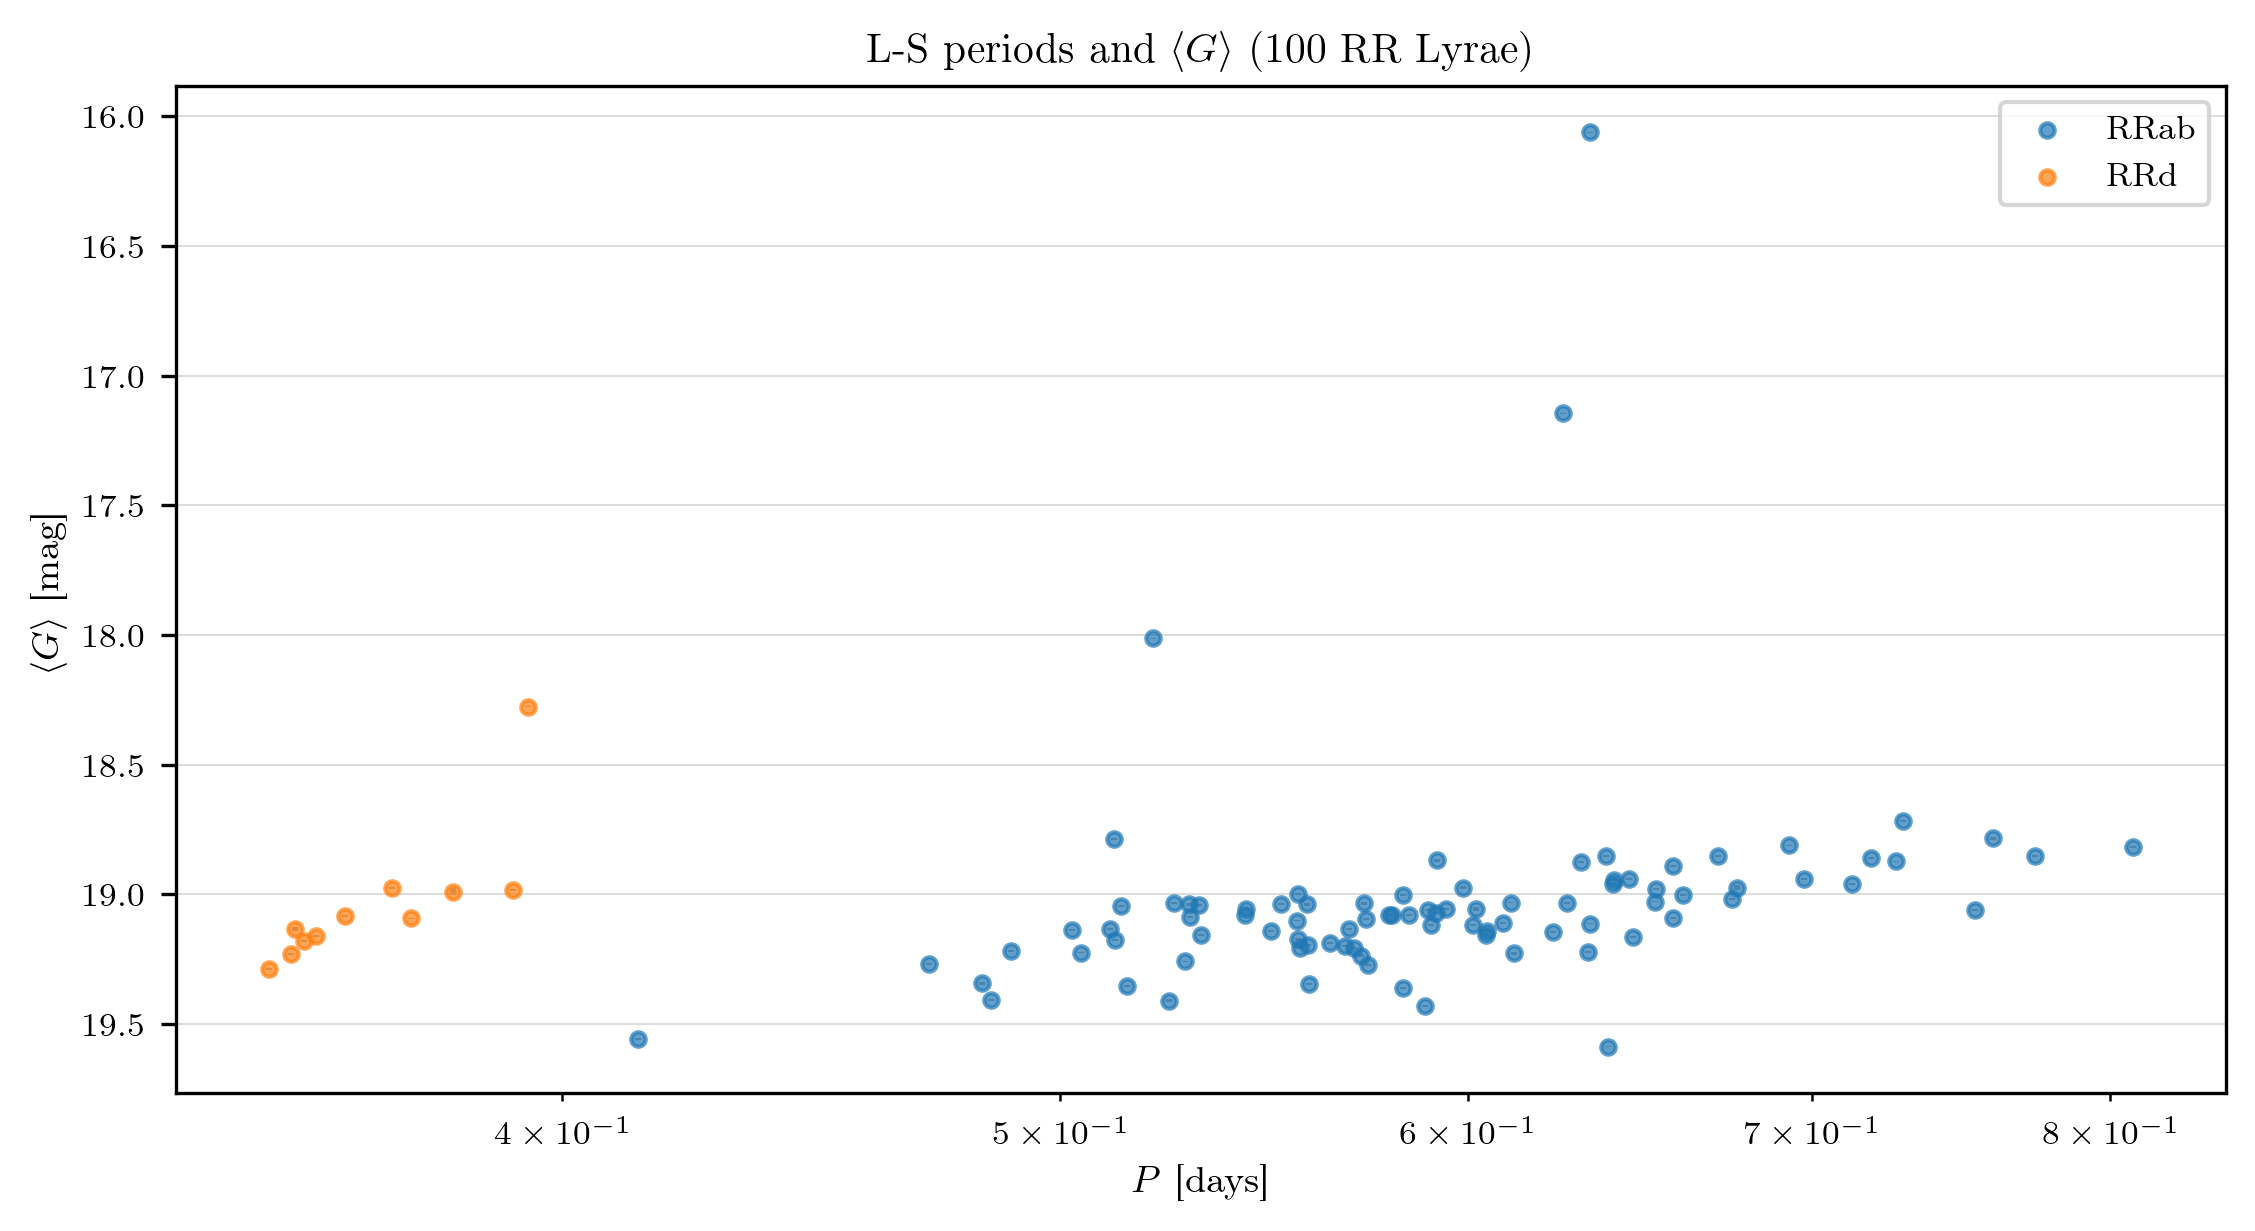

In [7]:
ax = plot_period_mean_g(summary)
plt.show()

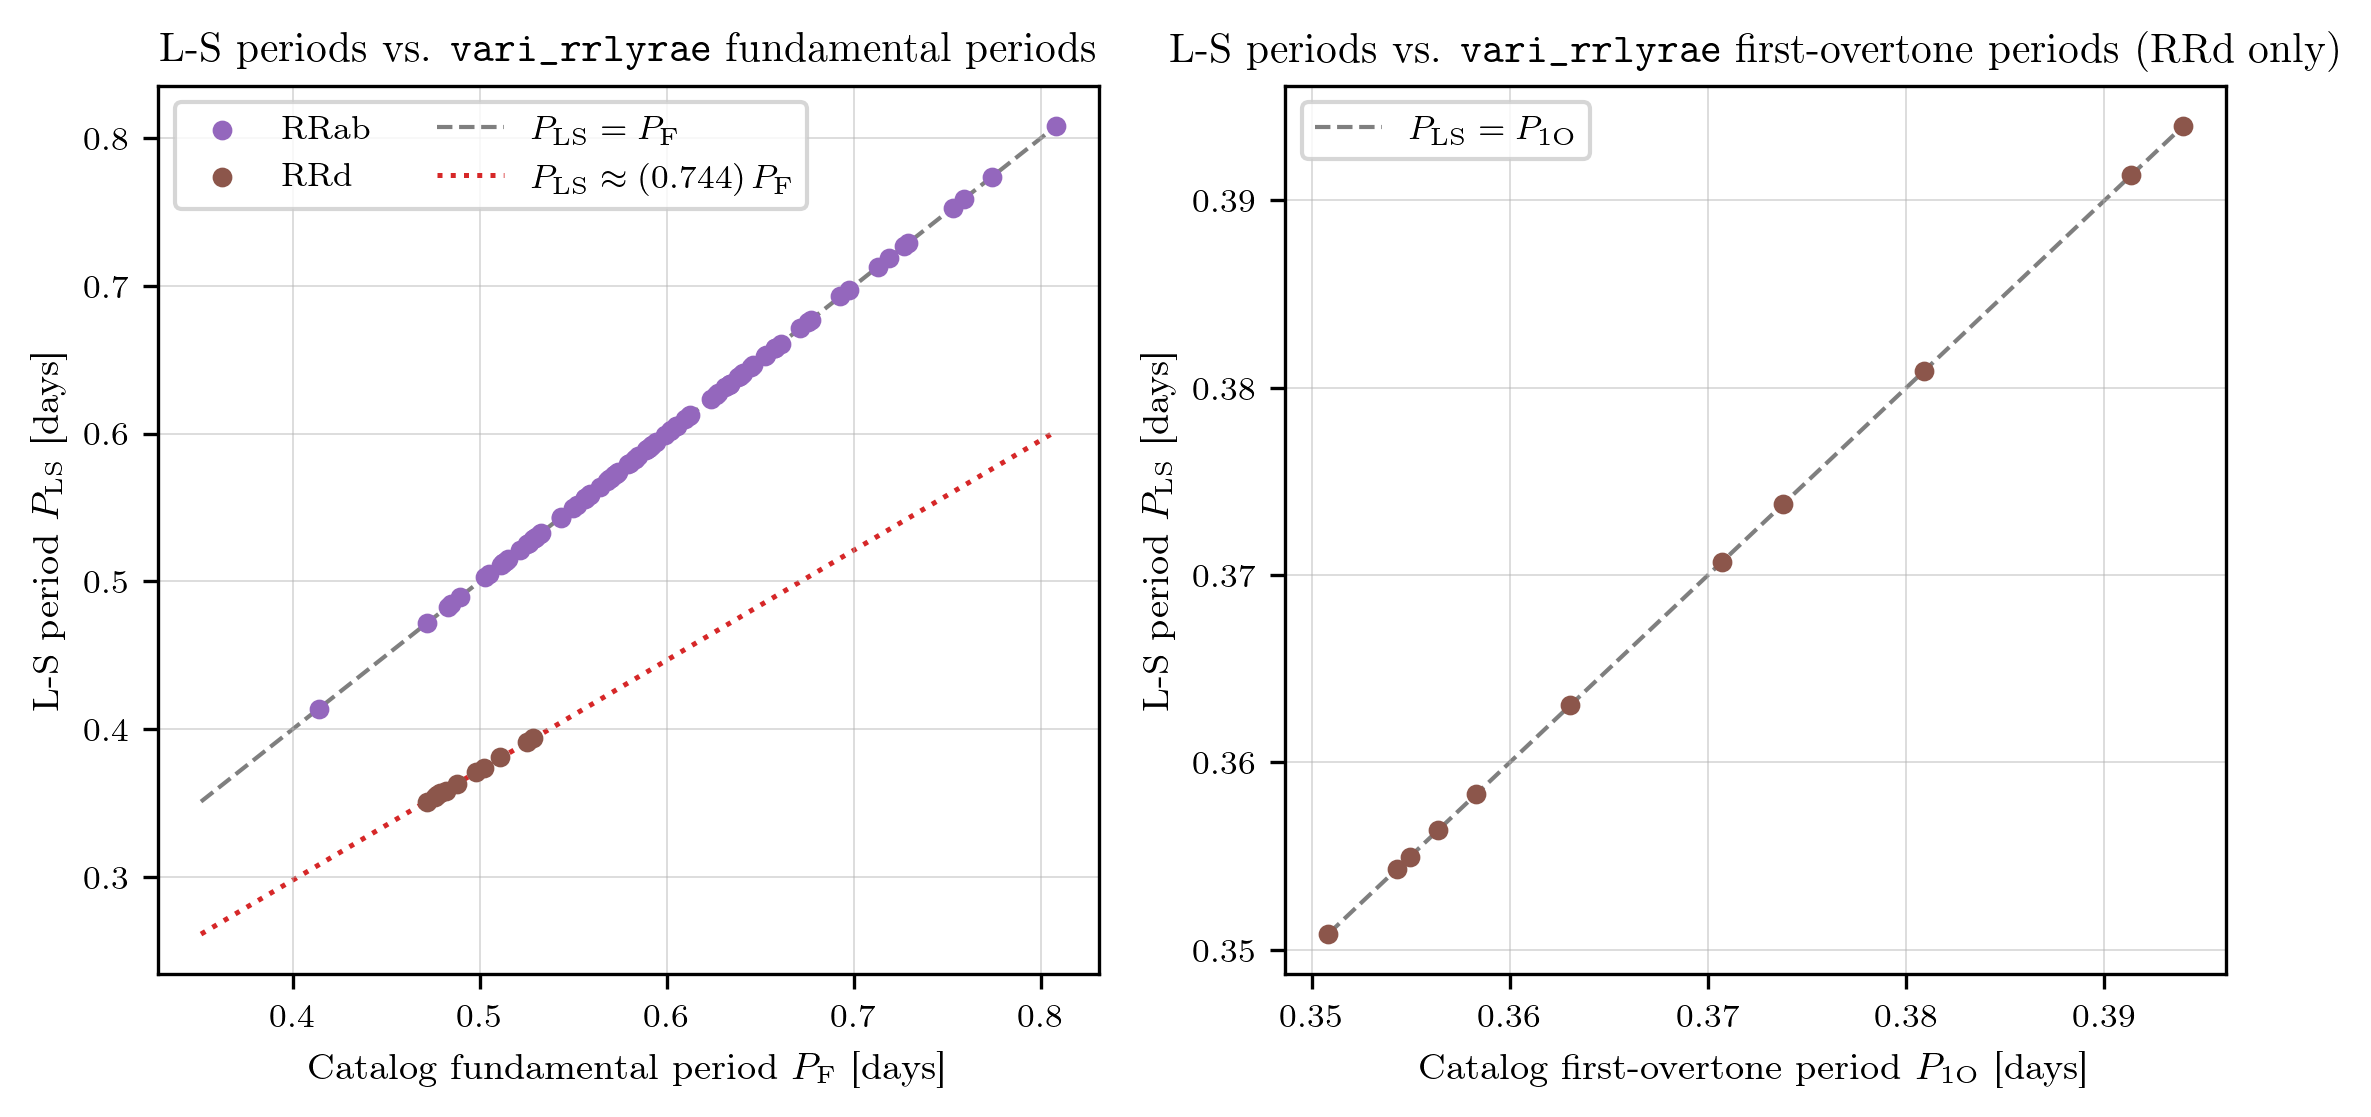

In [8]:
axes = plot_vari_rrlyrae_period_comparison(summary)
plt.show()

## Analysis and Discussion

The Lomb-Scargle periods are generally consistent with the `vari_rrlyrae` fundamental periods for these 100 stars. The median absolute period difference is **0.0000 d**, and the median absolute fractional difference is **0.00\%**. **89/100** stars agree to better than **1\%**, and **89/100** agree to better than **5\%**.

The largest discrepancy is for source **4659675509114516224**, where $P_{\rm F} = 0.4719\,\mathrm{d}$ and $P_{\rm LS} = 0.3508\,\mathrm{d}$. The fact that the stars with the largest period disagreements are RRd stars is physically reasonable. RRd stars are **double-mode RR Lyrae**, meaning they pulsate simultaneously in the **fundamental** and **first-overtone** radial modes. Gaia DR3 treats RRd stars as a distinct subclass, and the `vari_rrlyrae` table stores the two relevant periods separately as `pf` and `p1_o`.

Because this sample was queried with `pf IS NOT NULL`, the catalog comparison here is explicitly against the Gaia **fundamental period** `pf`. By contrast, the Lomb-Scargle analysis returns only a **single best period**. For an RRd star, that one-period summary can lock onto either pulsation mode, so disagreement with `pf` does **not** necessarily mean the period search failed. Instead, it usually means that a one-period model is too simple for a genuinely multi-periodic star.

For stars with both Gaia RRd periods available, the median catalog ratio is $P_{1\rm O}/P_{\rm F} = 0.744$. This is consistent with the standard RRd expectation that $P_1/P_0 \approx 0.74$--$0.75$.

The median ratio $P_{1\rm O}/P_{\rm LS} = 1.000$, which helps show whether the single-period Lomb-Scargle estimate is landing on the overtone branch rather than the fundamental branch.

This interpretation is supported by the RRd literature. Classical RRd stars occupy a narrow sequence in the Petersen diagram, and the **first overtone is often the stronger mode**, so a single-frequency Lomb-Scargle periodogram can preferentially recover `p1_o` even when the catalog comparison is being made against `pf`. Anomalous RRd stars can be more complicated still: they may have unusual period ratios, different dominant modes, or Blazhko-type modulation, all of which can broaden or complicate the periodogram.

So the main conclusion is that the RRd mismatches are best understood as a **mode-identification issue**, not simply as bad period recovery. A better comparison for RRd stars is to compare the Lomb-Scargle period to **both** Gaia catalog periods and ask whether it matches either `pf` or `p1_o`. Gaia's sparse cadence can also introduce alias structure, but the fact that the outliers cluster specifically in the RRd subclass points more strongly to **double-mode pulsation** as the dominant explanation.

### Sources
- G. Clementini et al. (2023), *Gaia Data Release 3 - Specific processing and validation of all-sky RR Lyrae and Cepheid stars: The RR Lyrae sample*, A&A 674, A18. https://www.aanda.org/articles/aa/full_html/2023/06/aa43964-22/aa43964-22.html
- Gaia DR3 `vari_rrlyrae` table metadata, including the definitions of `pf` and `p1_o`. https://gaia.aip.de/metadata/gaiadr3/vari_rrlyrae/
- K. Szczygiel & D. C. Fabrycky (2007), *Multiperiodic Galactic field RR Lyrae stars in the ASAS catalogue*, MNRAS 377, 1263. https://academic.oup.com/mnras/article/377/3/1263/1746832
- J. M. Nemec & P. Moskalik (2024), *Double-mode RR Lyrae stars observed by K2: analysis of high-precision Kepler photometry*, MNRAS 529, 296. https://academic.oup.com/mnras/article-abstract/529/1/296/7606327
- B. Holl et al. (2023), *Gaia Data Release 3 - Gaia scan-angle-dependent signals and spurious periods*, A&A 674, A25. https://www.aanda.org/articles/aa/full_html/2023/06/aa45353-22/aa45353-22.html
